# Loading Tracks from External Data Sources

Tracklib is designed to work with `Track` and `TrackCollection` objects, regardless of where the data comes from. If your data is stored in a format that is not natively supported, you can import it using any suitable Python library and convert it into Tracklib objects.

Importing data from an external source typically involves three steps:

* reading the observations,
* parsing timestamps into `ObsTime` objects,
* converting coordinates to the appropriate coordinate reference system (CRS).

## Example: Loading Tracks from a GeoPackage with Fiona

This example demonstrates how to load track data from a GeoPackage using the **Fiona** library.

The same pattern can be applied to any external data source, provided that observations, timestamps, and coordinates are converted into Tracklib objects.

### Installing Fiona

This example relies on the Fiona library to read GeoPackage files. If it is not already installed, install it with pip:

```
pip install fiona
```

### Import Libraries

The following imports are necessary for all of the examples.

In [1]:
import os
import sys

import fiona
import matplotlib.pyplot as plt

import tracklib as tkl

Code running in a no shapely environment


### Defining the Coordinate Reference System

The input data is stored in the geographic coordinate reference system (WGS84). In Tracklib, this corresponds to the GeoCoords (or equivalently GEO) coordinate type.

As a result, each observation is created using the GeoCoords class. For example:

In [2]:
o = tkl.GeoCoords(6.569672, 45.19995, 0)

### Defining the Timestamp Format

If your data contains timestamps, you must specify their format before importing the observations using the `ObsTime.setReadFormat()` method.

The format string describes how timestamps are represented in the input data. For example:

```Python
ObsTime.setReadFormat("4Y-2M-2DT2h:2m:2sZ")
```

By default, Tracklib expects timestamps in the following format: 

2D/2M/4Y 2h:2m:2s

In [3]:
# set format for timestamp
tkl.ObsTime.setReadFormat("4Y-2M-2DT2h:2m:2sZ")

### Loading the Data

The configuration is now complete and the data can be imported.

In this example, the tracks are stored in the "Bois de Vincennes" layer of the GeoPackage.

During the import, the observations are also converted from geographic coordinates to a planar coordinate system. This is recommended for most spatial analysis operations, such as distance, speed, interpolation, *etc.*.

In [4]:
filepath = '/home/md_vandamme/5_GPS/OV/Vincennes/Vincennes.gpkg'

collection = tkl.TrackCollection()

cpt = 1
with fiona.open(filepath, layer='Bois de Vincenne') as layer:
    for feature in layer:
        geom = feature['geometry']
        if geom.type == 'LineString':
            prop = feature.properties
            
            track_id = prop['track_id']
            trace = tkl.Track(track_id=track_id)
            
            coords = feature.geometry["coordinates"]
            for c in coords:
                time = tkl.ObsTime()
                point = tkl.Obs(tkl.GeoCoords(c[0], c[1], 0), time)
                trace.addObs(point)

            # Changement du système de référence: on projete en Lambert93
            trace.toProjCoords(2154)
            
            activity = prop['activity']
            if activity == 'walking' or activity == 'running':
                # on ajoute la trace 
                collection.addTrack(trace)
                cpt += 1
                if cpt%1200 == 0:
                    print (cpt)

        if cpt > 10000:
            break

print ("Nb traces:", collection.size())

1200
2400
3600
4800
6000
7200
8400
9600
Nb traces: 10000


### Filtering Data Within a Bounding Box

Rather than manipulating the entire dataset, we only want to keep tracks whose spatial extent intersects a given bounding box.

To do this, we first define a rectangular spatial constraint. Once the data has been imported, this constraint is applied to retain only the tracks whose spatial extent intersects the specified bounding box.

In [5]:
xMin = 657336
yMin = 6860189
xMax = 657890
yMax = 6860625

ll = tkl.ENUCoords(xMin, yMin)
ur = tkl.ENUCoords(xMax, yMax)
bbox = tkl.Rectangle(ll, ur)
constraintBBox = tkl.Constraint(shape = bbox, mode = tkl.MODE_INSIDE, type=tkl.TYPE_CUT_AND_SELECT)

lakeCollection = constraintBBox.select(collection)
print ('Number of tracks near the lake: ' + str(lakeCollection.size()))

Number of tracks near the lake: 2832


### Exporting the Data

Finally, export each track as a separate CSV file.

In [6]:
csvpath = '/home/md_vandamme/outdoorvision/'

tkl.TrackWriter.writeToFiles(lakeCollection, 
                             csvpath, 
                             ext='csv', id_E=0,id_N=1,id_U=2,id_T=3,h=1, separator=";")

### Visualizing the Data

Text(0.5, 1.0, 'Dataset of raw tracks')

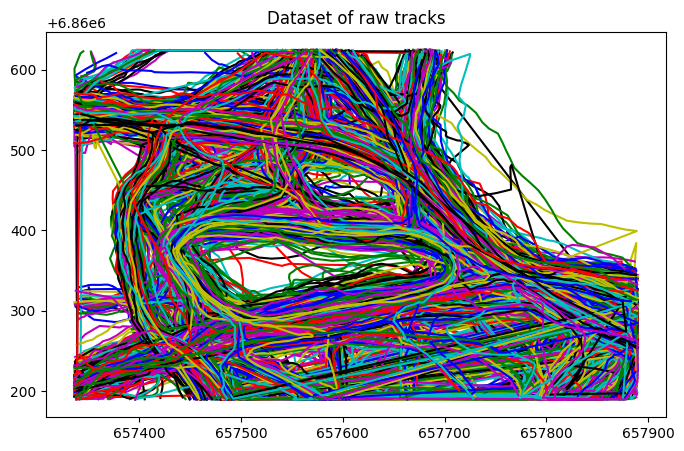

In [7]:
plt.figure(figsize=(8, 5))
lakeCollection.plot()
plt.title('Dataset of raw tracks')